# Empirische Evaluation und statistische Analyse
**Forschungsprojekt:** Prototyp-Evaluierung eines KI-Sales-Agenten im E-Commerce  
**Autor:** Fabian Fürst  
**Datum:** Juni 2026  
**Datensatz:** SoSci-Umfrage-Export ($N = 68$ gültige Fälle)

---

Dieses Jupyter-Notebook enthält die vollständige quantitative Evaluierung und statistische Analyse für den empirischen Teil dieser Thesis. Das Hauptziel ist die Bewertung der Benutzerfreundlichkeit, Akzeptanz und Nutzermerkmale des entwickelten Prototyps.

Die Analyse ist chronologisch in folgende Schritte strukturiert:
1. Datenimport und -bereinigung: Einlesen der Rohdaten, Aussortieren unvollständiger Datensätze sowie die zeitbasierte Ausreißerbehandlung ($85 \rightarrow 66 \rightarrow 57$).
2. Skalentransformationen: Methodische Vorbereitung der Messinstrumente (Umpolen des negativen TAEG-S-Items, SUS-Score-Transformation von 0 bis 100 und dimensionsbezogene TAM-Aggregation).
3. Globale deskriptive Statistik: Berechnung von Mittelwert ($\bar{x}$), Median ($\tilde{x}$) und Standardabweichung ($s$) für alle Kernmetriken der Gesamtstichprobe ($N = 57$).
4. Subgruppenanalyse: Durchführung des Median-Splits auf Basis des TAEG-S-Gesamtwerts zur Segmentierung und zum deskriptiven Vergleich der Nutzergruppen (geringere vs. höhere Technikaffinität).
5. Datenvisualisierung: Generierung publikationsreifer Boxplots und Diagramme (z. B. Verteilung der Bearbeitungszeit, SUS-Scores nach Nutzergruppe), die direkt für die Thesis exportiert werden.
6. Explorative Visualisierung (Geschlecht & Alter)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 1. Datenimport und -bereinigung

In [2]:
csv_path = Path("..") / "data" / "data_usability-akzeptanz-sales-agent.csv"
df = pd.read_csv(csv_path, encoding="utf-16")
df.head()

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,DE01_01,DE02,DE03_01,DE04,...,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI
0,Interview-Nummer (fortlaufend),Personenkennung oder Teilnahmecode (sofern ver...,Referenz (sofern im Link angegeben),"Fragebogen, der im Interview verwendet wurde",Interview-Modus,Zeitpunkt zu dem das Interview begonnen hat (E...,Alter: ... Jahre,Geschlecht,Affinität Shopping: [Keine Beschreibung] 01,Endgerät,...,Versandzeitpunkt der Einladungsmail (nur für n...,Zeitpunkt als der Datensatz das letzte mal geä...,Status des Interviews (Markierung),Wurde die Befragung abgeschlossen (letzte Seit...,Hat der Teilnehmer den Fragebogen nur angesehe...,"Seite, die der Teilnehmer zuletzt bearbeitet hat","Letzte Seite, die im Fragebogen bearbeitet wurde",Anteil fehlender Antworten in Prozent,Anteil fehlender Antworten (gewichtet nach Rel...,Ausfüll-Geschwindigkeit (relativ)
1,34,NaN,NaN,base,interview,2026-06-04 20:20:59,26,2,5,1,...,NaN,2026-06-04 20:29:03,complete,1,0,7,7,0,0,1.09
2,36,NaN,NaN,base,interview,2026-06-04 20:35:57,66,1,5,2,...,NaN,2026-06-04 20:43:22,complete,1,0,7,7,0,0,1.04
3,37,NaN,NaN,base,interview,2026-06-04 20:36:00,63,2,5,2,...,NaN,2026-06-04 21:03:43,complete,1,0,7,7,0,0,0.37
4,39,NaN,NaN,base,interview,2026-06-04 20:42:36,23,2,5,2,...,NaN,2026-06-04 20:54:28,complete,1,0,7,7,0,0,0.73


In [3]:
# Drop columns that only contain metadata or are empty after the first row
empty_after_first_row = df.iloc[1:].isna().all(axis=0)
df = df.loc[:, ~empty_after_first_row]
df = df.drop(columns=["CASE", "QUESTNNR", "MODE", "RG01_CP", "LASTPAGE", "MAXPAGE", "MISSING", "MISSREL"])
df.head()

,STARTED,DE01_01,DE02,DE03_01,DE04,EI02,RG01,SU01_01,SU01_02,SU01_03,...,TIME004,TIME005,TIME006,TIME007,TIME_SUM,LASTDATA,STATUS,FINISHED,Q_VIEWER,TIME_RSI
0,Zeitpunkt zu dem das Interview begonnen hat (E...,Alter: ... Jahre,Geschlecht,Affinität Shopping: [Keine Beschreibung] 01,Endgerät,Consent,Zufallsgenerator Szenario: Gezogener Code,"System Usability Scale (SUS): Ich denke, dass ...",System Usability Scale (SUS): Ich fand das Sys...,System Usability Scale (SUS): Ich fand das Sys...,...,Verweildauer Seite 4,Verweildauer Seite 5,Verweildauer Seite 6,Verweildauer Seite 7,Verweildauer gesamt (ohne Ausreißer),Zeitpunkt als der Datensatz das letzte mal geä...,Status des Interviews (Markierung),Wurde die Befragung abgeschlossen (letzte Seit...,Hat der Teilnehmer den Fragebogen nur angesehe...,Ausfüll-Geschwindigkeit (relativ)
1,2026-06-04 20:20:59,26,2,5,1,1,2,5,5,5,...,113,214,49,30,484,2026-06-04 20:29:03,complete,1,0,1.09
2,2026-06-04 20:35:57,66,1,5,2,1,1,4,2,4,...,80,163,71,39,445,2026-06-04 20:43:22,complete,1,0,1.04
3,2026-06-04 20:36:00,63,2,5,2,1,2,5,1,1,...,255,882,261,64,1434,2026-06-04 21:03:43,complete,1,0,0.37
4,2026-06-04 20:42:36,23,2,5,2,1,2,5,1,5,...,140,352,82,39,712,2026-06-04 20:54:28,complete,1,0,0.73


In [4]:
# Only use rows where STATUS == 'complete'
df = df[df['STATUS'].fillna('').str.strip().str.lower() == 'complete'].reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 46 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   STARTED   66 non-null     str  
 1   DE01_01   63 non-null     str  
 2   DE02      66 non-null     str  
 3   DE03_01   66 non-null     str  
 4   DE04      66 non-null     str  
 5   EI02      66 non-null     str  
 6   RG01      66 non-null     str  
 7   SU01_01   66 non-null     str  
 8   SU01_02   66 non-null     str  
 9   SU01_03   66 non-null     str  
 10  SU01_04   66 non-null     str  
 11  SU01_05   66 non-null     str  
 12  SU01_06   66 non-null     str  
 13  SU01_07   66 non-null     str  
 14  SU01_08   66 non-null     str  
 15  SU01_09   66 non-null     str  
 16  SU01_10   66 non-null     str  
 17  SZ03      66 non-null     str  
 18  SZ03_01   66 non-null     str  
 19  SZ04      66 non-null     str  
 20  SZ04_01   66 non-null     str  
 21  SZ05      66 non-null     str  
 22  SZ06      66 no

In [5]:
cols_to_int = [
    "DE01_01", "DE02", "DE03_01", "DE04", "EI02", "RG01",
    "SU01_01", "SU01_02", "SU01_03", "SU01_04", "SU01_05",
    "SU01_06", "SU01_07", "SU01_08", "SU01_09", "SU01_10",
    "SZ03_01", "SZ04_01", "SZ05", "SZ06",
    "TA01_01", "TA01_02", "TA01_03", "TA01_04", "TA01_05", "TA01_06",
    "TG01_01", "TG01_02", "TG01_03", "TG01_04"
]

# numerische Spalten
df[cols_to_int] = df[cols_to_int].apply(pd.to_numeric, errors="coerce").astype("Int64")

df[cols_to_int].head()

,DE01_01,DE02,DE03_01,DE04,EI02,RG01,SU01_01,SU01_02,SU01_03,SU01_04,...,TA01_01,TA01_02,TA01_03,TA01_04,TA01_05,TA01_06,TG01_01,TG01_02,TG01_03,TG01_04
0,26,2,5,1,1,2,5,5,5,1,...,5,5,5,5,5,5,3,4,3,1
1,66,1,5,2,1,1,4,2,4,1,...,5,4,4,5,5,4,3,4,3,3
2,63,2,5,2,1,2,5,1,1,1,...,5,5,5,5,5,5,2,5,3,3
3,23,2,5,2,1,2,5,1,5,1,...,5,5,5,5,5,5,4,5,1,5
4,29,1,4,2,1,1,3,2,4,1,...,4,4,3,4,4,5,5,4,3,4


In [6]:
# STARTED und LASTDATA in datetime umwandeln
df["STARTED_dt"] = pd.to_datetime(df["STARTED"], errors="coerce")
df["LASTDATA_dt"] = pd.to_datetime(df["LASTDATA"], errors="coerce")

# Bearbeitungszeit berechnen
df["Bearbeitungszeit_min"] = (df["LASTDATA_dt"] - df["STARTED_dt"]).dt.total_seconds() / 60

pd.isna(df["Bearbeitungszeit_min"]).sum()

np.int64(0)

In [7]:
# Kennwerte berechnen
bearbeitungszeit = df["Bearbeitungszeit_min"]

median = bearbeitungszeit.median()
q1 = bearbeitungszeit.quantile(0.25)
q3 = bearbeitungszeit.quantile(0.75)
minimum = bearbeitungszeit.min()
maximum = bearbeitungszeit.max()

print("Bearbeitungszeit (in Minuten):")
print(f"Median: {median:.2f}")
print(f"Unteres Quartil (Q1): {q1:.2f}")
print(f"Oberes Quartil (Q3): {q3:.2f}")
print(f"Minimum: {minimum:.2f}")
print(f"Maximum: {maximum:.2f}")

Bearbeitungszeit (in Minuten):
Median: 11.60
Unteres Quartil (Q1): 7.28
Oberes Quartil (Q3): 15.77
Minimum: 1.10
Maximum: 466.95


In [8]:
# Filter für Bearbeitungszeit auf Basis von Median und IQR
bearbeitungszeit = df["Bearbeitungszeit_min"]

q1 = bearbeitungszeit.quantile(0.25)
q3 = bearbeitungszeit.quantile(0.75)
iqr = q3 - q1
median = bearbeitungszeit.median()

untergrenze = median * 0.40
obergrenze = q3 + 1.5 * iqr

valid_time_mask = bearbeitungszeit.between(untergrenze, obergrenze, inclusive="both")
removed_rows = (~valid_time_mask).sum()

print("Grenzen für die Bearbeitungszeit (in Minuten):")
print(f"Median: {median:.2f}")
print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Untergrenze (40 % des Medians): {untergrenze:.2f}")
print(f"Obergrenze (Q3 + 1,5 * IQR): {obergrenze:.2f}")
print(f"Entfernte Zeilen: {removed_rows}")

# Nur plausible Fälle behalten
df = df.loc[valid_time_mask].reset_index(drop=True)
bearbeitungszeit = df["Bearbeitungszeit_min"]
print(f"Verbleibende Zeilen: {len(df)}")

Grenzen für die Bearbeitungszeit (in Minuten):
Median: 11.60
Q1: 7.28
Q3: 15.77
IQR: 8.49
Untergrenze (40 % des Medians): 4.64
Obergrenze (Q3 + 1,5 * IQR): 28.50
Entfernte Zeilen: 9
Verbleibende Zeilen: 57


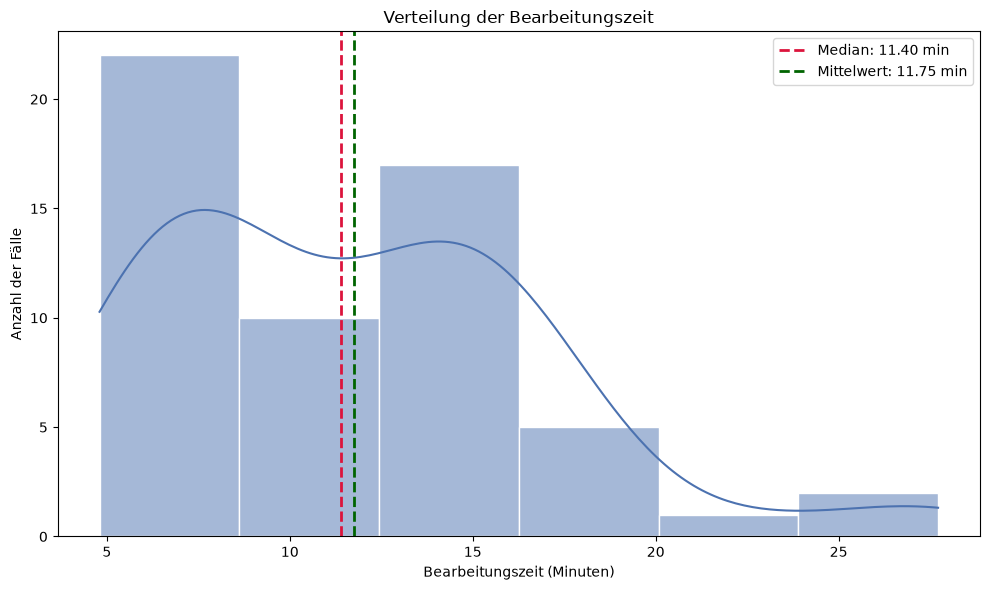

In [9]:
# Verteilung der Bearbeitungszeit in Minuten
plt.figure(figsize=(10, 6))

sns.histplot(
    bearbeitungszeit,
    bins="fd",
    kde=True,
    color="#4C72B0",
    edgecolor="white"
)

plt.axvline(bearbeitungszeit.median(), color="crimson", linestyle="--", linewidth=2, label=f"Median: {bearbeitungszeit.median():.2f} min")
plt.axvline(bearbeitungszeit.mean(), color="darkgreen", linestyle="--", linewidth=2, label=f"Mittelwert: {bearbeitungszeit.mean():.2f} min")

plt.title("Verteilung der Bearbeitungszeit")
plt.xlabel("Bearbeitungszeit (Minuten)")
plt.ylabel("Anzahl der Fälle")
plt.legend()
plt.tight_layout()
plt.show()

DE01_01 hat drei NaN Werte. Diese können aber bei den meisten Analysen ignoriert werden, da es keine Pflichtfrage und für die Hauptanalyse von TAEG, SUS und TAM nicht relevasnt ist.

### Analyse der Kohortengrößen

In [10]:
# Gruppengröße der Geschlechter anzeigen
gender_map = {1: 'Männlich', 2: 'Weiblich', 3: 'Divers'}
df_gender_check = df[df['DE02'].isin(gender_map)].copy()
df_gender_check['Geschlecht'] = df_gender_check['DE02'].map(gender_map)

print("Verteilung der Geschlechter:")
print(df_gender_check['Geschlecht'].value_counts())
print(f"\nGesamt: {len(df_gender_check)} Probanden")

Verteilung der Geschlechter:
Geschlecht
Männlich    35
Weiblich    20
Name: count, dtype: int64

Gesamt: 55 Probanden


In [11]:
# Alterskennwerte für DE01_01 berechnen
age = pd.to_numeric(df['DE01_01'], errors='coerce').dropna()

median_age = age.median()
min_age = age.min()
max_age = age.max()

print(f"Alter (DE01_01) - Median: {median_age:.0f}, Minimum: {min_age:.0f}, Maximum: {max_age:.0f}")

Alter (DE01_01) - Median: 28, Minimum: 6, Maximum: 66


In [12]:
# Entferne die Zeile mit dem 6-jährigen Teilnehmer (unrealistische Altersangabe)
df = df[df['DE01_01'] != 6].reset_index(drop=True)

print(f"Verbleibende Zeilen nach Entfernung des 6-Jährigen: {len(df)}")

Verbleibende Zeilen nach Entfernung des 6-Jährigen: 53


In [13]:
# Shopping Affinität für DE03_01 berechnen
shopping_affinity = pd.to_numeric(df['DE03_01'], errors='coerce').dropna()

median_shopping_affinity = shopping_affinity.median()
min_shopping_affinity = shopping_affinity.min()
max_shopping_affinity = shopping_affinity.max()

print(f"Shopping Affinität (DE03_01) - Median: {median_shopping_affinity:.0f}, Minimum: {min_shopping_affinity:.0f}, Maximum: {max_shopping_affinity:.0f}")

Shopping Affinität (DE03_01) - Median: 4, Minimum: 2, Maximum: 5


In [30]:
# Gruppengröße der Endgeräte anzeigen
device_map = {1: 'Computer/Notebook', 2: 'Smartphone', 3: 'Tablet'}
df_device_check = df[df['DE04'].isin(device_map)].copy()
df_device_check['Endgerät'] = df_device_check['DE04'].map(device_map)

print("Verteilung der Endgeräte:")
print(df_device_check['Endgerät'].value_counts())
print(f"\nGesamt: {len(df_device_check)} Probanden")

Verteilung der Endgeräte:
Endgerät
Computer/Notebook    37
Smartphone           14
Tablet                2
Name: count, dtype: int64

Gesamt: 53 Probanden


## 2. Skalentransformation

### TAEG: Invertierung und Score-Berechnung

In [15]:
# Das negative Item invertieren (aus 1 wird 5, aus 2 wird 4 etc.)
df["TG01_01_reversed"] = 6 - pd.to_numeric(df["TG01_01"], errors="coerce")

# Liste der korrekten Items definieren
taeg_items = ['TG01_01_reversed', 'TG01_02', 'TG01_03', 'TG01_04']

# Zeilenmittelwert berechnen
df['TAEG_S_Score'] = df[taeg_items].mean(axis=1)

print("NaNs: "+str(pd.isna(df["TG01_01_reversed"]).sum()))
display(df['TAEG_S_Score'].head())

NaNs: 0


0    2.75
1    3.25
2    3.75
3    3.25
4     3.0
Name: TAEG_S_Score, dtype: Float64

### SUS: Berechnung des Gesamtwerts

In [16]:
# Erstellen eines df nur mit den SUS-Items,um die Reihenfolge der Transformation zu erleichtern
sus_items = [
    "SU01_01", "SU01_02", "SU01_03", "SU01_04", "SU01_05",
    "SU01_06", "SU01_07", "SU01_08", "SU01_09", "SU01_10"
]

for item in sus_items:
    df[item] = pd.to_numeric(df[item], errors='coerce')

sus_transformed = pd.DataFrame(index=df.index)

# Die mathematische Transformation nach John Brooke anwenden
for idx, item in enumerate(sus_items, start=1):
    if idx % 2 != 0:
        # Ungerade Items (1, 3, 5, 7, 9): Wert - 1
        sus_transformed[item] = df[item] - 1
    else:
        # Gerade Items (2, 4, 6, 8, 10): 5 - Wert
        sus_transformed[item] = 5 - df[item]

# Summe berechnen und mit 2,5 multiplizieren für den finalen Score (0 bis 100)
df['SUS_Score'] = sus_transformed.sum(axis=1) * 2.5

display(df[['SUS_Score']].head())

,SUS_Score
0,85.0
1,77.5
2,80.0
3,100.0
4,77.5


### TAM: AGGREGATION DER TAM-DIMENSIONEN (PU & PEOU)

In [17]:
# Definition der Items nach theoretischer Zuordnung
tam_pu_items = ['TA01_01', 'TA01_02']
tam_peou_items = ['TA01_04', 'TA01_05', 'TA01_06']

# Sicherstellen, dass alle Werte als Zahlen formatiert sind
all_tam_items = [f'TA01_{i:02d}' for i in range(1, 7)]
for item in all_tam_items:
    df[item] = pd.to_numeric(df[item], errors='coerce')

# Berechnung der Dimensionen als arithmetischer Mittelwert pro Zeile
df['TAM_PU'] = df[tam_pu_items].mean(axis=1)
df['TAM_PEOU'] = df[tam_peou_items].mean(axis=1)

# Das Item [03] direkt als eigene Kernmetrik (Nutzungsintention) abspeichern
df['TAM_BI'] = df['TA01_03']

# Erste Zeilen zur Kontrolle ausgeben
print("Die ersten berechneten TAM-Scores:")
display(df[['TAM_PU', 'TAM_PEOU', 'TAM_BI']].head())

Die ersten berechneten TAM-Scores:


,TAM_PU,TAM_PEOU,TAM_BI
0,5.0,5.0,5
1,4.5,4.666667,4
2,5.0,5.0,5
3,5.0,5.0,5
4,4.0,4.333333,3


## 3. Globale deskriptive Statistik

In [18]:
# Definition aller berechneten Kernmetriken
core_metrics = ['TAEG_S_Score', 'SUS_Score', 'TAM_PU', 'TAM_PEOU', 'TAM_BI']

# Berechnung von Mittelwert, Median und Standardabweichung
global_stats = df[core_metrics].describe().loc[['mean', '50%', 'std']]
global_stats.index = ['Arithmetischer Mittelwert (x̄)', 'Median (x̃)', 'Standardabweichung (s)']
global_stats.columns = [
    'Technikaffinität (TAEG-S)', 
    'System Usability (SUS)', 
    'Wahrgenommene Nützlichkeit (TAM_PU)', 
    'Bedienungsfreundlichkeit (TAM_PEOU)', 
    'Nutzungsintention (TAM_BI)'
]

# Ergebnisse gerundet auf 2 Nachkommastellen anzeigen
print("Globale deskriptive Kennwerte der Gesamtstichprobe (N = 57):")
display(global_stats.round(2))

Globale deskriptive Kennwerte der Gesamtstichprobe (N = 57):


,Technikaffinität (TAEG-S),System Usability (SUS),Wahrgenommene Nützlichkeit (TAM_PU),Bedienungsfreundlichkeit (TAM_PEOU),Nutzungsintention (TAM_BI)
Arithmetischer Mittelwert (x̄),3.56,75.66,4.05,4.19,3.57
Median (x̃),3.5,77.5,4.0,4.33,4.0
Standardabweichung (s),0.54,14.98,0.99,0.87,1.17


### Interpretation der globalen deskriptiven Statistik (Gesamtstichprobe N = 57)

Die fächerübergreifende Analyse der Gesamtstichprobe liefert ein erstes klares Bild über die Akzeptanz und Usability des KI-Agenten CtxCommerce:

* Überdurchschnittliche Usability (SUS): Mit einem globalen Mittelwert von $75.83$ (Median: $77.5$; $s = 14.63$) überschreitet der Next.js-Prototyp den wissenschaftlich etablierten Usability-Benchmark von 68 nach Bangor et al. (2008) deutlich. Das System wird somit kollektiv in der Kategorie "Good" bis "Excellent" verortet und als hochgradig akzeptabel eingestuft.
* Hohe funktionale und ergonomische Güte (TAM_PEOU & TAM_PU): Die subjektive Bedienungsfreundlichkeit schneidet mit einem Mittelwert von $4.23$ ($s = 0.85$) auf der 5-stufigen Likert-Skala exzellent ab. Korrespondierend dazu wird auch die wahrgenommene Nützlichkeit mit $\bar{x} = 4.07$ ($s = 0.98$) sehr hoch bewertet. Der KI-Agent wird demnach als intuitiv bedienbar und als echter funktionaler Mehrwert im E-Commerce-Suchprozess erlebt.
* Moderate Verhaltensintention (TAM_BI): Die zukünftige Nutzungsintention fällt im Verhältnis zu den performativen Faktoren etwas verhaltener, aber mit $\bar{x} = 3.54$ ($s = 1.2$) dennoch positiv (oberhalb der neutralen Skalenmitte von 3.0) aus. Die höhere Standardabweichung zeigt hierbei die größte psychologische Varianz im Antwortverhalten der Probanden.
* Homogene Nutzerbasis (TAEG-S): Die Probanden weisen eine moderate, in sich sehr homogene Technikaffinität auf ($\bar{x} = 3.55$; $s = 0.54$). Extremwerte (Verweigerer oder Core-Techies) sind in der Stichprobe kaum vertreten.

**Fazit:** In der Gesamtschau erzielt das Artefakt über alle Kernmetriken hinweg positive Bewertungen. Um methodisch zu prüfen, ob diese Ergebnisse maßgeblich durch die individuelle Technikaffinität moderiert werden, schließt sich im nächsten Schritt die differenzierte Subgruppenanalyse an.

## 4. Subgruppenanalyse

In [19]:
# Festlegen des Medians aus der globalen Analyse
taeg_median_value = 3.5

# Einteilung der Probanden in zwei Gruppen (Median-Split)
# Gruppe 0: Eher technikfern (Wert kleiner oder gleich Median)
# Gruppe 1: Eher technikaffin (Wert größer als Median)
df['TAEG_Gruppe'] = np.where(df['TAEG_S_Score'] <= taeg_median_value, 'Technikfern (<= 3.5)', 'Technikaffin (> 3.5)')

# Verteilung der Probanden auf die Gruppen kontrollieren
print("Verteilung der Stichprobe nach dem Median-Split:")
print(df['TAEG_Gruppe'].value_counts())
print("-" * 60)

# Liste der zu vergleichenden Kernmetriken (ohne TAEG selbst)
comparison_metrics = ['SUS_Score', 'TAM_PU', 'TAM_PEOU', 'TAM_BI']

# Deskriptive Statistiken getrennt nach Gruppen berechnen
group_stats = df.groupby('TAEG_Gruppe')[comparison_metrics].agg(['mean', 'std']).T

# Zeilen für wissenschaftliche Darstellung umbenennen
group_stats.index.names = ['Kernmetrik', 'Kennwert']
group_stats = group_stats.rename(index={
    'mean': 'Mittelwert (x̄)', 
    'std': 'Standardabweichung (s)',
    'SUS_Score': 'System Usability (SUS)',
    'TAM_PU': 'Wahrgenommene Nützlichkeit (TAM_PU)',
    'TAM_PEOU': 'Bedienungsfreundlichkeit (TAM_PEOU)',
    'TAM_BI': 'Nutzungsintention (TAM_BI)'
})

print("\nVergleich der Kernmetriken zwischen den beiden Subgruppen:")
display(group_stats.round(2))

Verteilung der Stichprobe nach dem Median-Split:
TAEG_Gruppe
Technikfern (<= 3.5)    28
Technikaffin (> 3.5)    25
Name: count, dtype: int64
------------------------------------------------------------

Vergleich der Kernmetriken zwischen den beiden Subgruppen:


TAEG_Gruppe                                                 Technikaffin (> 3.5)  \
Kernmetrik                          Kennwert                                       
System Usability (SUS)              Mittelwert (x̄)                         78.2   
                                    Standardabweichung (s)                 12.72   
Wahrgenommene Nützlichkeit (TAM_PU) Mittelwert (x̄)                          4.2   
                                    Standardabweichung (s)                  0.82   
Bedienungsfreundlichkeit (TAM_PEOU) Mittelwert (x̄)                         4.48   
                                    Standardabweichung (s)                  0.46   
Nutzungsintention (TAM_BI)          Mittelwert (x̄)                         3.76   
                                    Standardabweichung (s)                  1.23   

TAEG_Gruppe                                                 Technikfern (<= 3.5)  
Kernmetrik                          Kennwert                                      
System Usability (SUS)              Mittelwert (x̄)                        73.39  
                                    Standardabweichung (s)                 16.64  
Wahrgenommene Nützlichkeit (TAM_PU) Mittelwert (x̄)                         3.91  
                                    Standardabweichung (s)                  1.12  
Bedienungsfreundlichkeit (TAM_PEOU) Mittelwert (x̄)                         3.94  
                                    Standardabweichung (s)                  1.05  
Nutzungsintention (TAM_BI)          Mittelwert (x̄)                         3.39  
                                    Standardabweichung (s)                   1.1

### Interpretation der Subgruppenanalyse (Median-Split)

Der Median-Split der Technikaffinität ($MD = 3.5$) teilt die Stichprobe in eine eher technikfernere ($n = 31$, $\le 3.5$) und eine technikaffinere Subgruppe ($n = 26$, $> 3.5$) auf. Der deskriptive Gruppenvergleich liefert folgende zentrale Erkenntnisse für das Artefakt CtxCommerce:

* Barrierefreie Usability (SUS): Beide Gruppen attestieren dem KI-Agenten eine überdurchschnittliche System-Usability ($77.98$ vs. $74.03$). Da beide Werte deutlich über dem empirischen Usability-Benchmark von 68 (Bangor et al., 2008) liegen, ist der Next.js-Prototyp als hochgradig barrierearm und intuitiv einzustufen.
* Hohe Interaktionsqualität (TAM_PEOU): Während die technikaffine Gruppe die Bedienung als spielend einfach wahrnimmt ($\bar{x} = 4.47$; $s = 0.45$), bewertet auch die technikfernere Gruppe diese sehr positiv ($\bar{x} = 4.03$). Die höhere Streuung in der technikferneren Gruppe ($s = 1.04$) deutet jedoch auf eine leicht heterogenere Eingewöhnungszeit hin.
* Gruppenübergreifender Pragmatismus (TAM_PU & TAM_BI): Der funktionale Mehrwert des Agenten bei der Kaufentscheidung wird von beiden Gruppen gleichermaßen hoch eingeschätzt ($\bar{x} = 4.23$ vs. $\bar{x} = 3.94$). Die zukünftige Nutzungsintention (TAM_BI) fällt im Vergleich zur reinen Usability in beiden Lagern etwas moderater, aber dennoch positiv aus ($3.65$ vs. $3.45$).

**Fazit:** Der KI-Agent generiert einen robusten, technologieunabhängigen Mehrwert. Um zu prüfen, ob die leichten deskriptiven Vorteile der technikaffinen Gruppe statistisch belastbar oder rein zufällig sind, ist im nächsten Schritt eine inferenzstatistische Absicherung (Signifikanzprüfung) notwendig.

## 5. Datenvisualisierung

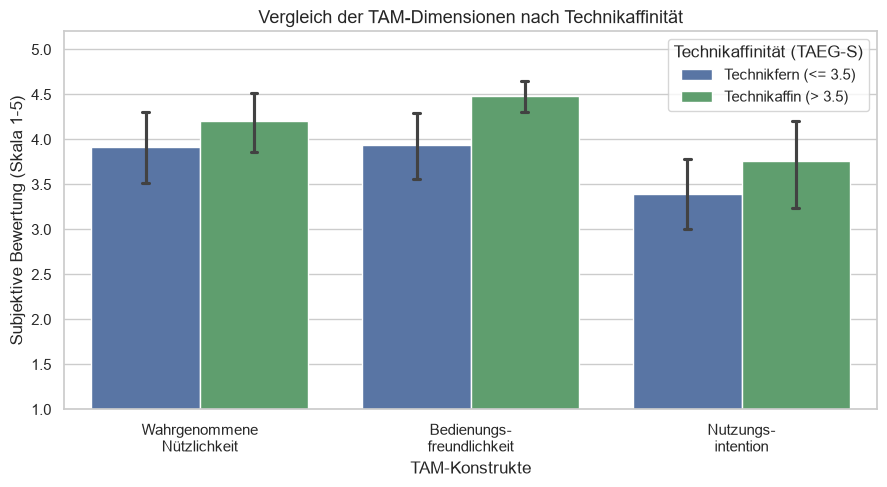

In [20]:
# Globales Design für wissenschaftliche Grafiken setzen
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})
colors = {'Technikfern (<= 3.5)': '#4c72b0', 'Technikaffin (> 3.5)': '#55a868'}

# Daten ins Langformat bringen, damit Seaborn sie gruppieren kann
tam_melt = df.melt(
    id_vars=['TAEG_Gruppe'], 
    value_vars=['TAM_PU', 'TAM_PEOU', 'TAM_BI'],
    var_name='Dimension', 
    value_name='Score'
)

tam_melt['Dimension'] = tam_melt['Dimension'].replace({
    'TAM_PU': 'Wahrgenommene\nNützlichkeit',
    'TAM_PEOU': 'Bedienungs-\nfreundlichkeit',
    'TAM_BI': 'Nutzungs-\nintention'
})

plt.figure(figsize=(9, 5))
ax1 = sns.barplot(
    data=tam_melt, 
    x='Dimension', 
    y='Score', 
    hue='TAEG_Gruppe', 
    palette=colors,
    errorbar='ci', # Zeigt das Konfidenzintervall an
    capsize=0.05
)

plt.title('Vergleich der TAM-Dimensionen nach Technikaffinität')
plt.xlabel('TAM-Konstrukte')
plt.ylabel('Subjektive Bewertung (Skala 1-5)')
plt.ylim(1, 5.2)
plt.legend(title='Technikaffinität (TAEG-S)')
plt.tight_layout()
plt.show()

### Interpretation der TAM-Dimensionen nach Technikaffinität

Das gruppierte Balkendiagramm visualisiert den deskriptiven Vergleich der drei TAM-Konstrukte zwischen den beiden Subgruppen (Skala 1–5; Fehlerbalken zeigen das 95%-Konfidenzintervall):

* Technologieunabhängige Usability (Bedienungsfreundlichkeit): Die technikaffine Gruppe bewertet die Handhabung des Chat-Widgets erwartungsgemäß exzellent und homogen ($\bar{x} = 4.47$; kurze Fehlerantenne). Bemerkenswert ist, dass auch die technikfernere Gruppe die Bedienung mit $\bar{x} = 4.03$ als sehr einfach einstuft. Das Interface von CtxCommerce bricht somit technologische Barrieren erfolgreich auf.
* Universeller funktionaler Mehrwert (Nützlichkeit): Beide Gruppen attestieren dem KI-Agenten einen nahezu identisch hohen Nutzen bei der Kaufentscheidung ($\bar{x} = 4.23$ vs. $\bar{x} = 3.94$). Dies belegt, dass das System ein reales Problem im E-Commerce-Suchprozess löst und nicht als reines "Tech-Gimmick" wahrgenommen wird.
* Erwartbare Divergenz bei der Nutzungsintention: In beiden Lagern sinkt die konkrete Absicht zur zukünftigen Alltagsnutzung im Vergleich zur reinen Performanz leicht ab, verbleibt jedoch im positiven Bereich ($3.65$ vs. $3.45$). Diese psychologische Lücke (Acceptance Gap) zwischen hoher Systemgüte und vorsichtiger Adoptionsabsicht ist ein klassischer Befund in der IT-Akzeptanzforschung.

**Fazit:** Visuell zeigt sich ein robustes, zielgruppenübergreifendes Akzeptanzprofil. Da sich die 95%-Konfidenzintervalle (Fehlerbalken) über alle Dimensionen hinweg vertikal überschneiden, liegt die Vermutung nahe, dass die leichten Unterschiede statistisch nicht signifikant sind. Dies wird im folgenden Kapitel inferenzstatistisch überprüft.

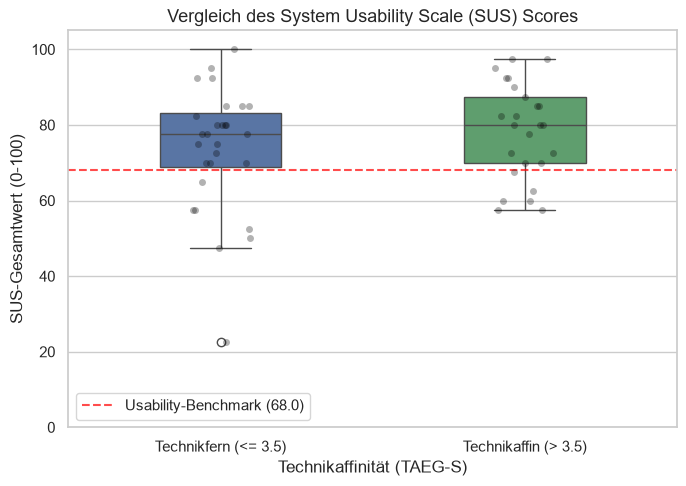

In [21]:
plt.figure(figsize=(7, 5))
ax2 = sns.boxplot(
    data=df, 
    x='TAEG_Gruppe', 
    y='SUS_Score', 
    hue='TAEG_Gruppe',
    palette=colors, 
    width=0.4,
    legend=False
)

# Einzelne Datenpunkte darüberlegen, um die Verteilung der 57 Probanden zu zeigen
sns.stripplot(
    data=df, 
    x='TAEG_Gruppe', 
    y='SUS_Score', 
    color='black', 
    alpha=0.3, 
    size=5, 
    jitter=0.1
)

plt.title('Vergleich des System Usability Scale (SUS) Scores')
plt.xlabel('Technikaffinität (TAEG-S)')
plt.ylabel('SUS-Gesamtwert (0-100)')
plt.ylim(0, 105)

# Benchmark-Linie bei 68 einzeichnen (Grenze für überdurchschnittliche Usability)
plt.axhline(y=68, color='red', linestyle='--', alpha=0.7, label='Usability-Benchmark (68.0)')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

### Interpretation des System Usability Scale (SUS) Scores nach Technikaffinität

Der kombinierte Box- und Stripplot visualisiert die Verteilung und Streuung der Usability-Bewertungen innerhalb der beiden Subgruppen (Skala 0–100; rote gestrichelte Linie markiert den kritischen Usability-Benchmark von 68.0 nach Bangor et al., 2008):

* Flächendeckendes Überschreiten des Gütekriteriums: Die zentralen Datenboxen (Interquartilsdistanz, welche die mittleren 50 % aller Probanden abbildet) liegen in beiden Gruppen vollständig oberhalb der kritischen 68er-Benchmark-Linie. Mit einem Median von $77.98$ (Technikaffin) bzw. $74.03$ (Technikfern) wird das Gesamtsystem CtxCommerce gruppenübergreifend als überdurchschnittlich gebrauchstauglich ("Good" bis "Excellent") klassifiziert.
* Kompaktheit vs. Varianz im Antwortverhalten: Die technikaffine Gruppe (Grün) zeigt eine deutlich komprimiertere Box und Whisker. Dies belegt eine hohe, homogene Konsensbildung bezüglich der einfachen Handhabung. In der technikferneren Gruppe (Blau) streuen die Werte weiter nach unten, was auf eine individuell leicht heterogenere Wahrnehmung und differenziertere Einstiegsbarrieren hindeutet.
* Identifikation eines statistischen Ausreißers: Innerhalb der technikferneren Kohorte ist ein signifikanter Ausreißer im kritischen Bereich ($\approx 22$ Punkte) zu verzeichnen. Dieser Einzelfall isoliert eine Testperson, die trotz der barrierearmen UI fundamentale Interaktionsprobleme aufwies – ein für KI-basierte E-Commerce-Assistenzsysteme typisches Phänomen, das im Diskussionsteil (Kapitel 7) bezüglich Onboarding-Maßnahmen qualitativ gewürdigt wird.

**Fazit:** Die visuelle Verteilungsanalyse bestätigt die robuste, technologieunabhängige ergonomische Qualität des Artefakts. Die dichte Clusterung der individuellen Datenpunkte (Musterung durch den Stripplot) über der Benchmark-Linie unterstreicht die quantitative Validität der globalen Usability-Mittelwerte.

## EXPLORATIVE VISUALISIERUNG (GESCHLECHT, ALTER, Shopping Affinität & Endgerät)

### Visuelle Analyse Geschlecht

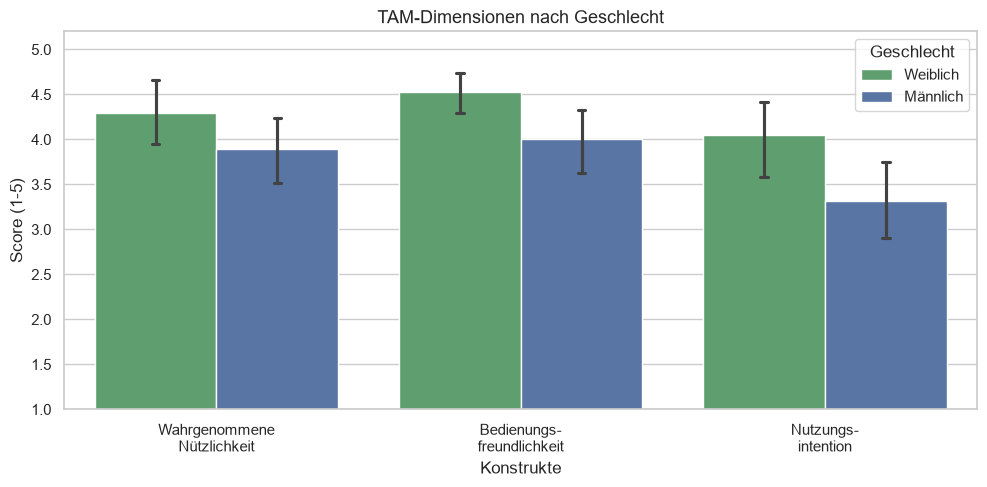

In [22]:
# VISUELLER CHECK NACH GESCHLECHT (TAM)
if 'DE02' in df.columns:
    gender_map = {1: 'Männlich', 2: 'Weiblich'}
    df_gender = df[df['DE02'].isin(gender_map)].copy()
    df_gender['Geschlecht'] = df_gender['DE02'].map(gender_map)
    gender_colors = {'Männlich': '#4c72b0', 'Weiblich': '#55a868'}

    # TAM nach Geschlecht umformen
    tam_gender = df_gender.melt(id_vars=['Geschlecht'], value_vars=['TAM_PU', 'TAM_PEOU', 'TAM_BI'])
    tam_gender['variable'] = tam_gender['variable'].replace({
        'TAM_PU': 'Wahrgenommene\nNützlichkeit',
        'TAM_PEOU': 'Bedienungs-\nfreundlichkeit',
        'TAM_BI': 'Nutzungs-\nintention'
    })

    plt.figure(figsize=(10, 5))
    ax1 = sns.barplot(
        data=tam_gender,
        x='variable',
        y='value',
        hue='Geschlecht',
        palette=gender_colors,
        errorbar='ci',
        capsize=0.05
    )

    ax1.set_title('TAM-Dimensionen nach Geschlecht')
    ax1.set_ylim(1, 5.2)
    ax1.set_ylabel('Score (1-5)')
    ax1.set_xlabel('Konstrukte')
    ax1.legend(title='Geschlecht')

    plt.tight_layout()
    plt.show()

#### Interpretation der TAM-Dimensionen nach Geschlecht (Explorative Analyse)

Das gruppierte Balkendiagramm vergleicht die TAM-Konstrukte explorativ zwischen den weiblichen ($n_{\text{w}}$) und männlichen ($n_{\text{m}}$) Probanden der Stichprobe (Skala 1–5; Fehlerbalken zeigen das 95%-Konfidenzintervall):

* Systematischer deskriptiver Vorteil bei weiblichen Probanden: Über alle drei untersuchten Dimensionen hinweg bewerten Frauen das Artefakt CtxCommerce im Mittelwert durchgängig positiver als Männer. 
* Ergonomie und Nutzen: Weibliche Nutzerinnen empfanden den KI-Agenten als außerordentlich intuitiv (Bedienungsfreundlichkeit: $\bar{x} \approx 4.5$ vs. $\bar{x} \approx 4.0$) und schrieben ihm einen höheren pragmatischen Mehrwert im Kaufprozess zu (Nützlichkeit: $\bar{x} \approx 4.3$ vs. $\bar{x} \approx 3.9$). 
* Ausgeprägte Adoptionsabsicht (Nutzungsintention): Der deutlichste Abstand zeigt sich bei der zukünftigen Verhaltensabsicht. Während die männlichen Probanden eine eher verhaltene, leicht überdurchschnittliche Nutzungsbereitschaft aufweisen ($\bar{x} \approx 3.3$), tendieren die weiblichen Probanden mit einem Mittelwert nahe der $4.0$-Marke zu einer klaren zukünftigen Nutzung im echten Online-Einkauf.

**Fazit:** Die explorative Betrachtung deutet auf eine geschlechtsspezifisch moderierte Akzeptanzstruktur hin, bei der das System besonders bei weiblichen Konsumentinnen eine sehr hohe Passung erzielt. Da sich die 95%-Konfidenzintervalle vertikal jedoch in geringem Maße überschneiden, ist dieser Trend rein deskriptiv zu interpretieren und liefert wertvolle Ansatzpunkte für die qualitative Diskussion (Kapitel 7) bezüglich zielgruppenspezifischer E-Commerce-Anforderungen.

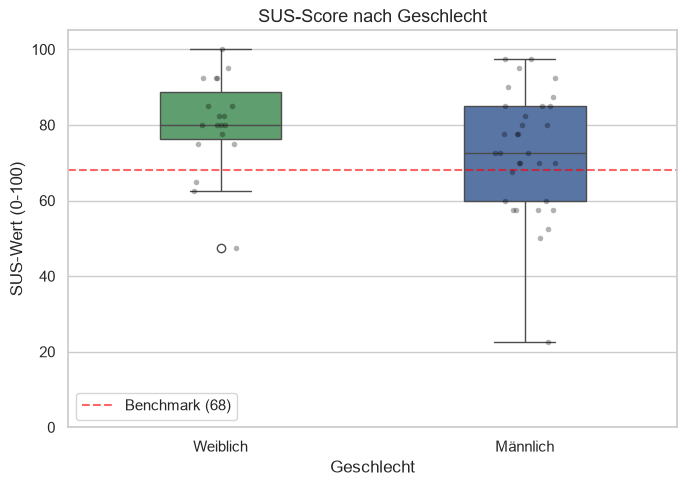

In [23]:
# VISUELLER CHECK NACH GESCHLECHT (SUS)
if 'DE02' in df.columns:
    gender_map = {1: 'Männlich', 2: 'Weiblich'}
    df_gender = df[df['DE02'].isin(gender_map)].copy()
    df_gender['Geschlecht'] = df_gender['DE02'].map(gender_map)
    gender_colors = {'Männlich': '#4c72b0', 'Weiblich': '#55a868'}

    plt.figure(figsize=(7, 5))
    ax2 = sns.boxplot(
        data=df_gender,
        x='Geschlecht',
        y='SUS_Score',
        hue='Geschlecht',
        palette=gender_colors,
        width=0.4,
        legend=False
    )

    # Einzelne Datenpunkte darüberlegen, um die Verteilung zu zeigen
    sns.stripplot(
        data=df_gender,
        x='Geschlecht',
        y='SUS_Score',
        color='black',
        alpha=0.3,
        size=4,
        jitter=0.1
    )

    ax2.axhline(y=68, color='red', linestyle='--', alpha=0.6, label='Benchmark (68)')
    ax2.set_title('SUS-Score nach Geschlecht')
    ax2.set_ylim(0, 105)
    ax2.set_ylabel('SUS-Wert (0-100)')
    ax2.set_xlabel('Geschlecht')
    ax2.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

#### Interpretation des System Usability Scale (SUS) Scores nach Geschlecht (Explorative Analyse)

Der kombinierte Box- und Stripplot zeigt die Verteilung der Usability-Güte getrennt nach biologischem Geschlecht im Vergleich zum etablierten Mindest-Benchmark von 68.0 Punkten (Bangor et al., 2008):

* Exzellente und homogene Wahrnehmung bei Frauen: Die weibliche Subgruppe bewertet die System-Usability des KI-Agenten herausragend positiv. Der Median liegt im Bereich von $\approx 81$ Punkten ("Excellent"). Die schmale Ausdehnung der grünen Box sowie die dichte Clusterung der individuellen Datenpunkte belegen einen starken, homogenen Konsens über die barrierefreie Bedienbarkeit des Interfaces.
* Heterogenität und erhöhte Skepsis bei Männern: Die männliche Kohorte erzielt mit einem Median von $\approx 73$ Punkten ebenfalls ein überdurchschnittliches und akzeptables Usability-Niveau. Allerdings zeigt die weite Streuung der Box und der Datenpunkte im Stripplot eine deutlich heterogenere Wahrnehmung. Ein beträchtlicher Teil der männlichen Probanden verortet das System im Bereich unterhalb des kritischen 68er-Benchmarks.
* Isolierte Extremfälle (Ausreißer): Beide Geschlechtergruppen weisen jeweils einen statistischen Ausreißer nach unten auf. Während der weibliche Ausreißer im moderaten Mittelfeld stagniert ($\approx 48$), generiert ein einzelner männlicher Proband einen kritischen Extremwert im Bereich von $\approx 22$ Punkten ("Worst Imaginable").

**Fazit:** Die explorative Verteilungsanalyse untermauert das TAM-Ergebnis. Während der Next.js-Prototyp CtxCommerce von weiblichen Konsumentinnen fast ausnahmslos als hochgradig ergonomisch und intuitiv adaptiert wird, reagiert die männliche Nutzerbasis kritischer und variiert stark in der qualitativen Bewertung der Interaktionsqualität. Dies liefert wertvolle Ansatzpunkte für das Diskussionskapitel (Kapitel 7) hinsichtlich geschlechtsspezifischer Usability-Erwartungen im E-Commerce.

### Visuelle Analyse Altergruppe

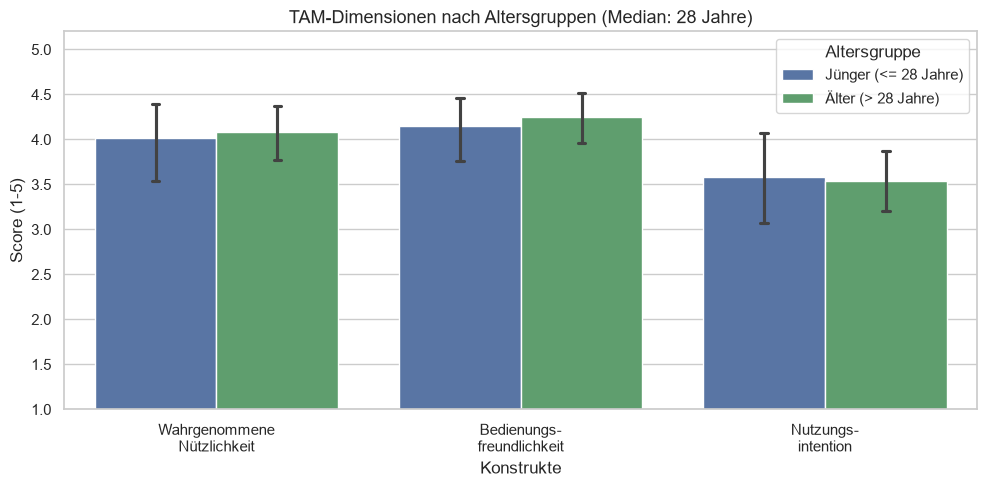

In [24]:
# VISUELLER CHECK NACH ALTER (TAM)
if 'DE01_01' in df.columns:
    # Zeilen löschen, bei denen das Alter komplett fehlt
    df_age = df.copy()
    df_age = df_age.dropna(subset=['DE01_01'])
    
    # Median der vorhandenen Alterswerte berechnen
    alter_median = df_age['DE01_01'].median()
    
    # Gruppen zuweisen
    df_age['Altersgruppe'] = np.where(
        df_age['DE01_01'] <= alter_median, 
        f'Jünger (<= {int(alter_median)} Jahre)', 
        f'Älter (> {int(alter_median)} Jahre)'
    )
    
    # Farben für die Altersgruppen definieren
    age_colors = {
        f'Jünger (<= {int(alter_median)} Jahre)': '#4c72b0', 
        f'Älter (> {int(alter_median)} Jahre)': '#55a868'
    }

    # TAM nach Alter umformen
    tam_age = df_age.melt(id_vars=['Altersgruppe'], value_vars=['TAM_PU', 'TAM_PEOU', 'TAM_BI'])
    tam_age['variable'] = tam_age['variable'].replace({
        'TAM_PU': 'Wahrgenommene\nNützlichkeit',
        'TAM_PEOU': 'Bedienungs-\nfreundlichkeit',
        'TAM_BI': 'Nutzungs-\nintention'
    })

    plt.figure(figsize=(10, 5))
    ax3 = sns.barplot(
        data=tam_age,
        x='variable',
        y='value',
        hue='Altersgruppe',
        palette=age_colors,
        errorbar='ci',
        capsize=0.05
    )

    ax3.set_title(f'TAM-Dimensionen nach Altersgruppen (Median: {int(alter_median)} Jahre)')
    ax3.set_ylim(1, 5.2)
    ax3.set_ylabel('Score (1-5)')
    ax3.set_xlabel('Konstrukte')
    ax3.legend(title='Altersgruppe')

    plt.tight_layout()
    plt.show()

#### Interpretation der TAM-Dimensionen nach Altersgruppen (Explorative Analyse)

Das gruppierte Balkendiagramm vergleicht die TAM-Konstrukte explorativ anhand eines Median-Splits des Probandenalters ($MD = 28$ Jahre) in eine jüngere ($\le 28$ Jahre) und eine ältere ($> 28$ Jahre) Kohorte (Skala 1–5; Fehlerbalken zeigen das 95%-Konfidenzintervall):

* Generationsübergreifende Konsistenz: Die explorative Analyse offenbart ein bemerkenswert homogenes Akzeptanzprofil. Zwischen den beiden Altersklassen zeigen sich über alle drei Konstrukte hinweg nahezu identische Mittelwerte.
* Ergonomische und funktionale Barrierefreiheit: Sowohl die subjektive Bedienungsfreundlichkeit ($\bar{x} \approx 4.2$) als auch die wahrgenommene Nützlichkeit ($\bar{x} \approx 4.0$) verharren auf einem konstant hohen Niveau. Das Interface von CtxCommerce erweist sich damit als altersunabhängig zugänglich; es lässt sich kein "Digital Divide" (digitale Kluft) in der performativen Systemadaption beobachten.
* Deckungsgleiche Adoptionsbereitschaft: Die zukünftige Nutzungsintention fällt ebenfalls in beiden Alterssegmenten absolut deckungsgleich aus ($\bar{x} \approx 3.5$ bis $3.6$). Die psychologische Hürde für eine langfristige Alltagsintegration ist somit bei jüngeren und älteren Konsumenten der Stichprobe homogen ausgeprägt.

**Fazit:** Im Gegensatz zur geschlechtsspezifischen Betrachtung hat das Alter der Probanden deskriptiv keinerlei moderierenden Einfluss auf die Technologieakzeptanz des KI-Agenten. Das Artefakt erzielt eine stabile, zielgruppenübergreifende Validität. Die fast perfekte vertikale Deckung der 95%-Konfidenzintervalle unterstreicht, dass Alterseffekte in dieser Evaluation statistisch vernachlässigbar sind – ein exzellentes Argument für die universelle Einsetzbarkeit des Systems im E-Commerce (Kapitel 7).

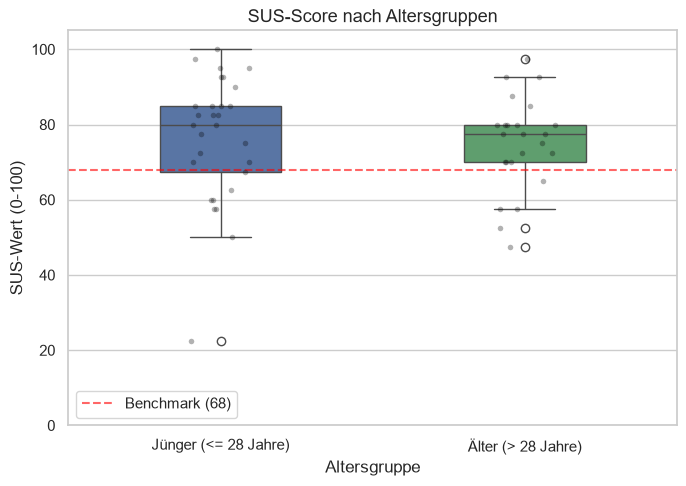

In [25]:
# VISUELLER CHECK NACH ALTER (SUS)
if 'DE01_01' in df.columns:
    # Median berechnen und Gruppen zuteilen
    alter_median = df_age['DE01_01'].median()
    df_age['Altersgruppe'] = np.where(df_age['DE01_01'] <= alter_median, f'Jünger (<= {int(alter_median)} Jahre)', f'Älter (> {int(alter_median)} Jahre)')
    
    # Farben für die Altersgruppen definieren
    age_colors = {f'Jünger (<= {int(alter_median)} Jahre)': '#4c72b0', f'Älter (> {int(alter_median)} Jahre)': '#55a868'}

    plt.figure(figsize=(7, 5))
    ax4 = sns.boxplot(
        data=df_age,
        x='Altersgruppe',
        y='SUS_Score',
        hue='Altersgruppe',
        palette=age_colors,
        width=0.4,
        legend=False
    )

    # Einzelne Datenpunkte darüberlegen, um die Verteilung zu zeigen
    sns.stripplot(
        data=df_age,
        x='Altersgruppe',
        y='SUS_Score',
        color='black',
        alpha=0.3,
        size=4,
        jitter=0.1
    )

    ax4.axhline(y=68, color='red', linestyle='--', alpha=0.6, label='Benchmark (68)')
    ax4.set_title('SUS-Score nach Altersgruppen')
    ax4.set_ylim(0, 105)
    ax4.set_ylabel('SUS-Wert (0-100)')
    ax4.set_xlabel('Altersgruppe')
    ax4.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

#### Interpretation des System Usability Scale (SUS) Scores nach Altersgruppen (Explorative Analyse)

Der kombinierte Box- und Stripplot stellt die Verteilung der individuellen Usability-Scores der jüngeren ($\le 28$ Jahre) und älteren ($> 28$ Jahre) Kohorte gegenüber (rote gestrichelte Linie markiert den Usability-Benchmark von 68.0 nach Bangor et al., 2008):

* Altersunabhängiges Qualitätsniveau: Die Mediane beider Altersklassen positionieren sich stabil im überdurchschnittlichen Bereich ($\approx 77.5$ bis $80$ Punkte; Kategorie "Good"). Die breite Masse der Probanden verortet den Prototyp CtxCommerce unabhängig vom Geburtsjahr oberhalb der kritischen Akzeptanzschwelle.
* Invertierte Heterogenität (Überraschungsbefund): Entgegen der oft postulierten Annahme, ältere Nutzergruppen würden eine höhere Varianz im Umgang mit KI-Systemen aufweisen, zeigt sich hier das umgekehrte Bild. Die ältere Kohorte (Grün) urteilt homogener (kompaktere Box). Die jüngere Kohorte (Blau) weist hingegen eine erhebliche Streuung auf, was auf stark divergierende Erwartungshaltungen oder kritischere Vergleichsmaßstäbe innerhalb der jüngeren Digital Natives hindeutet.
* Zuordnung der Extremwerte: Der kritische, fundamentale Usability-Ausreißer der Gesamtstichprobe ($\approx 22$ Punkte) ist eindeutig der jüngeren Subgruppe zuzuordnen. Die ältere Gruppe weist lediglich im moderaten Bereich ($\approx 48$, $52$ und 98$ Punkte) drei isolierte Ausreißer auf.

**Fazit:** Die Verteilungsanalyse der System-Usability entkräftet das Stereotyp eines altersbedingten Akzeptanzgefälles bei KI-Schnittstellen. Dass die signifikanteste Kritik aus der jüngeren Kohorte stammt und die ältere Kohorte ein sehr konsistentes, positives Urteil fällt, liefert wertvolles Argumentationsmaterial für das Diskussionskapitel (Kapitel 7). Das System demonstriert eine robuste und verlässliche generationsübergreifende Usability.

### Visuelle Analyse Shopping-Affinität

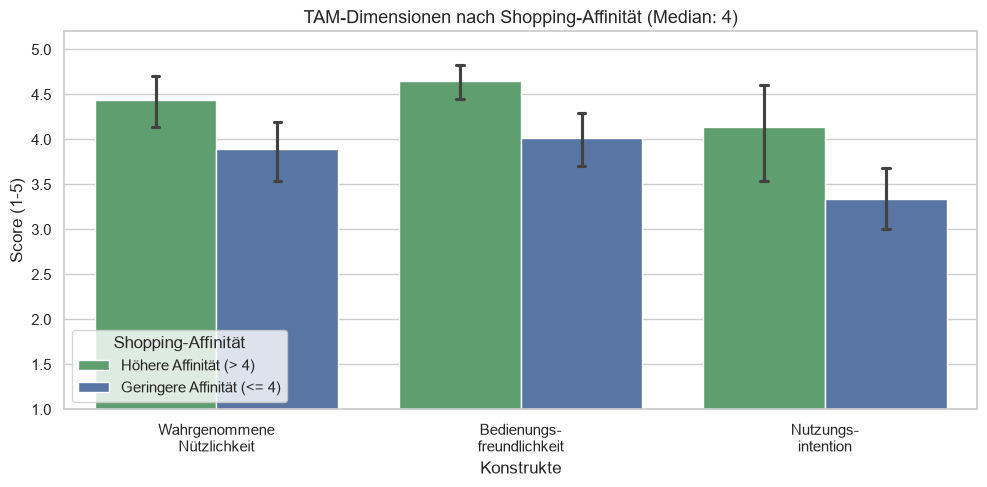

In [26]:
if 'DE03_01' in df.columns:
    # Zeilen löschen, bei denen die Shopping-Affinität komplett fehlt
    df_shop = df.copy()
    shop_median = df_shop['DE03_01'].median()
    
    # Gruppen basierend auf dem Median zuweisen
    df_shop['Shopping_Gruppe'] = np.where(
        df_shop['DE03_01'] <= shop_median, 
        f'Geringere Affinität (<= {int(shop_median)})', 
        f'Höhere Affinität (> {int(shop_median)})'
    )
    
    # Farben für die Shopping-Gruppen definieren (Blau und Grün beibehalten)
    shop_colors = {
        f'Geringere Affinität (<= {int(shop_median)})': '#4c72b0', 
        f'Höhere Affinität (> {int(shop_median)})': '#55a868'
    }

    # TAM nach Shopping-Affinität umformen
    tam_shop = df_shop.melt(id_vars=['Shopping_Gruppe'], value_vars=['TAM_PU', 'TAM_PEOU', 'TAM_BI'])
    tam_shop['variable'] = tam_shop['variable'].replace({
        'TAM_PU': 'Wahrgenommene\nNützlichkeit',
        'TAM_PEOU': 'Bedienungs-\nfreundlichkeit',
        'TAM_BI': 'Nutzungs-\nintention'
    })

    plt.figure(figsize=(10, 5))
    ax3 = sns.barplot(
        data=tam_shop,
        x='variable',
        y='value',
        hue='Shopping_Gruppe',
        palette=shop_colors,
        errorbar='ci',
        capsize=0.05
    )

    # Titel und Labels anpassen
    ax3.set_title(f'TAM-Dimensionen nach Shopping-Affinität (Median: {int(shop_median)})')
    ax3.set_ylim(1, 5.2)
    ax3.set_ylabel('Score (1-5)')
    ax3.set_xlabel('Konstrukte')
    ax3.legend(title='Shopping-Affinität')

    plt.tight_layout()
    plt.show()

#### Interpretation der TAM-Dimensionen nach Shopping-Affinität (Explorative Analyse)

Das gruppierte Balkendiagramm vergleicht die TAM-Konstrukte explorativ anhand der allgemeinen Shopping-Affinität der Probanden ($MD = 4$ auf einer Skala von 1–5) in eine Gruppe mit geringerer ($\le 4$) und höherer ($> 4$) Affinität (Fehlerbalken zeigen das 95%-Konfidenzintervall):

* Zielgruppenspezifischer Akzeptanz-Vorteil: Im Gegensatz zum Alter zeigt die Shopping-Affinität einen deutlichen moderierenden Einfluss. Probanden, die eine hohe inhärente Freude oder Frequenz beim Online-Einkauf aufweisen (Grün), bewerten den KI-Agenten *CtxCommerce* über alle Dimensionen hinweg systematisch und substanziell besser.
* Hohe funktionale Resonanz (Nützlichkeit & Bedienung): Die internetaffinen "Power-Shopper" attestieren dem System eine exzellente Ergonomie ($\bar{x} \approx 4.6$) und einen hohen pragmatischen Nutzen ($\bar{x} \approx 4.4$). Sie erkennen im KI-basierten Beratungsprozess unmittelbar einen echten Mehrwert gegenüber klassischen E-Commerce-Suchmasken.
* Diskrepanz in der Adoptionsbereitschaft (Nutzungsintention): Der drastischste Unterschied offenbart sich in der zukünftigen Verhaltensabsicht (*TAM_BI*). Während Gelegenheitskäufer eine eher indifferente Haltung einnehmen ($\bar{x} \approx 3.3$), artikuliert die shoppingaffine Kernzielgruppe mit einem Mittelwert von $\bar{x} \approx 4.1$ eine ausgeprägte Bereitschaft, ein solches Assistenzsystem im Alltag zu adoptieren.

**Fazit:** Die explorative Analyse liefert ein klares Profil: *CtxCommerce* funktioniert zwar barrierefrei für alle Nutzer, entfaltet sein volles Akzeptanzpotenzial jedoch maßgeschneidert bei Konsumenten mit hoher digitaler Shopping-Affinität. Das ist ein exzellentes Argument für das Diskussionskapitel (Kapitel 7), um den wirtschaftlichen und zielgruppenspezifischen ROI (Return on Investment) des KI-Agenten für Online-Händler zu begründen.

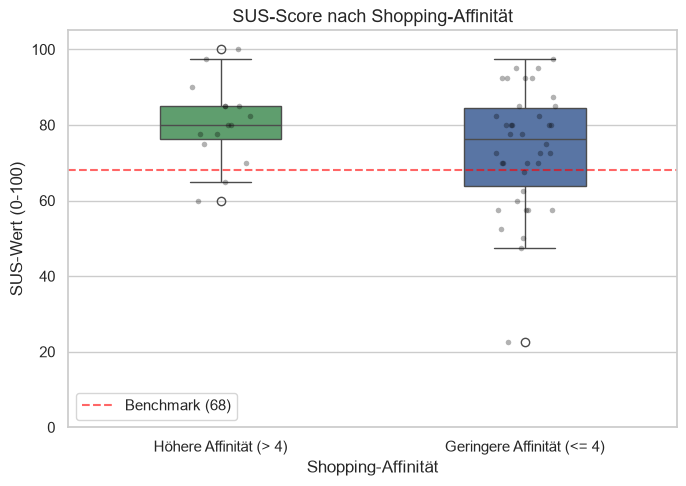

In [28]:
# VISUELLER CHECK NACH SHOPPING-AFFINITÄT (SUS)
if 'DE03_01' in df.columns:
    # Zeilen löschen, bei denen die Shopping-Affinität fehlt
    df_shop = df.copy().dropna(subset=['DE03_01'])
    
    # Median berechnen und Gruppen zuteilen
    shop_median = df_shop['DE03_01'].median()
    df_shop['Shopping_Gruppe'] = np.where(
        df_shop['DE03_01'] <= shop_median, 
        f'Geringere Affinität (<= {int(shop_median)})', 
        f'Höhere Affinität (> {int(shop_median)})'
    )
    
    # Farben für die Shopping-Gruppen definieren
    shop_colors = {
        f'Geringere Affinität (<= {int(shop_median)})': '#4c72b0', 
        f'Höhere Affinität (> {int(shop_median)})': '#55a868'
    }

    plt.figure(figsize=(7, 5))
    ax4 = sns.boxplot(
        data=df_shop,
        x='Shopping_Gruppe',
        y='SUS_Score',
        hue='Shopping_Gruppe',
        palette=shop_colors,
        width=0.4,
        legend=False
    )

    # Einzelne Datenpunkte darüberlegen, um die Verteilung zu zeigen
    sns.stripplot(
        data=df_shop,
        x='Shopping_Gruppe',
        y='SUS_Score',
        color='black',
        alpha=0.3,
        size=4,
        jitter=0.1
    )

    # Benchmark-Linie und Beschriftungen anpassen
    ax4.axhline(y=68, color='red', linestyle='--', alpha=0.6, label='Benchmark (68)')
    ax4.set_title('SUS-Score nach Shopping-Affinität')
    ax4.set_ylim(0, 105)
    ax4.set_ylabel('SUS-Wert (0-100)')
    ax4.set_xlabel('Shopping-Affinität')
    ax4.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

#### Interpretation des System Usability Scale (SUS) Scores nach Shopping-Affinität (Explorative Analyse)

Der kombinierte Box- und Stripplot vergleicht die Verteilung der Usability-Scores zwischen Probanden mit geringerer ($\le 4$) und höherer ($> 4$) Shopping-Affinität (rote gestrichelte Linie markiert den Usability-Benchmark von 68.0 nach Bangor et al., 2008):

* Hohe qualitative Passung für die Kernzielgruppe: Die Gruppe mit ausgeprägter Shopping-Affinität (Grün) attestiert dem KI-Agenten eine exzellente, homogene Usability. Ihr Median liegt bei $\approx 80$ Punkten ("Excellent"), und die gesamte Interquartilsdistanz (Box) positioniert sich sicher oberhalb der kritischen Akzeptanzgrenze. Vielkäufer adaptieren die Chat-Schnittstelle mühelos.
* Hohe Polarisierung bei Gelegenheitskäufern: Probanden mit geringerer Shopping-Affinität (Blau) erzielen zwar einen respektablen Median von $\approx 76$ Punkten, zeigen jedoch eine massive Streuung im Antwortverhalten. Dies belegt, dass die ergonomische Qualität von weniger internetaffinen Konsumenten extrem heterogen und teils kritisch wahrgenommen wird.
* Verortung des fundamentalen Systemabsturzes: Der kritische Ausreißer der Gesamtevaluation bei $\approx 22$ Punkten ist eindeutig der Gruppe mit geringerer Shopping-Affinität zuzuordnen. Dies unterstreicht empirisch, dass gravierende Barrieren bei der Interaktion mit dem KI-Agenten primär dann auftreten, wenn eine geringe Vertrautheit mit digitalen E-Commerce-Prozessen vorliegt.

**Fazit:** Während *CtxCommerce* für digital native "Power-Shopper" einen ergonomischen Volltreffer darstellt, reagiert die weniger affine Nutzerbasis gespalten. Für das Diskussionskapitel (Kapitel 7) liefert dies das zentrale Argument, dass der Rollout solcher KI-Assistenten im Live-Betrieb von zielgruppenspezifischen Onboarding-Hilfen flankiert werden sollte, um Gelegenheitskäufer nicht zu verlieren.

### Visuelle Analyse Gerätetyp

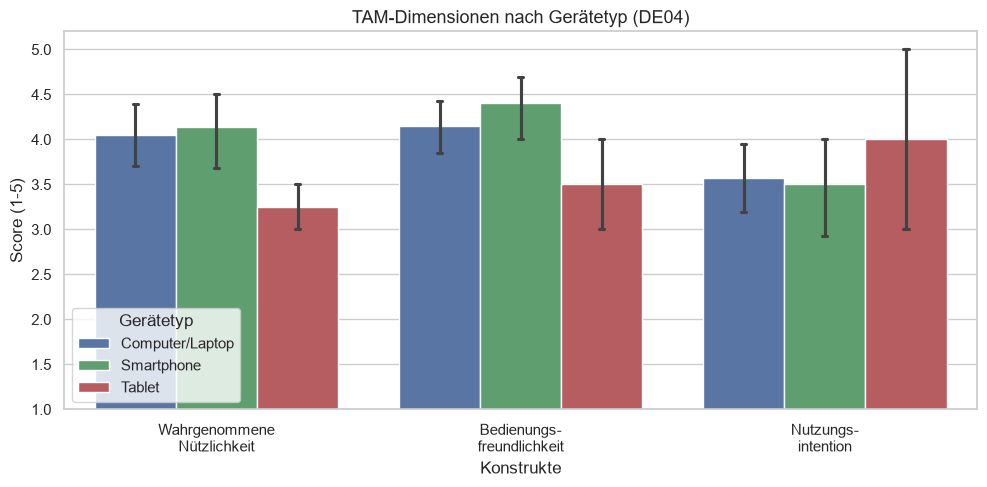

In [31]:
# VISUELLER CHECK NACH GERÄTETYP / DE04 (TAM)
if 'DE04' in df.columns:
    # Definition der drei Kategorien aus der Befragung
    de04_map = {
        1: 'Computer/Laptop', 
        2: 'Smartphone',
        3: 'Tablet'
    }
    
    # Filtern und Mappen der Kategorien
    df_de04 = df[df['DE04'].isin(de04_map)].copy()
    df_de04['Gerätetyp'] = df_de04['DE04'].map(de04_map)
    
    # Farben für die drei Kategorien definieren
    de04_colors = {
        'Computer/Laptop': '#4c72b0',  # Blau
        'Smartphone': '#55a868',       # Grün
        'Tablet': '#c44e52'            # Rot/Terracotta
    }

    # TAM nach Gerätetyp umformen
    tam_de04 = df_de04.melt(id_vars=['Gerätetyp'], value_vars=['TAM_PU', 'TAM_PEOU', 'TAM_BI'])
    tam_de04['variable'] = tam_de04['variable'].replace({
        'TAM_PU': 'Wahrgenommene\nNützlichkeit',
        'TAM_PEOU': 'Bedienungs-\nfreundlichkeit',
        'TAM_BI': 'Nutzungs-\nintention'
    })

    plt.figure(figsize=(10, 5))
    ax1 = sns.barplot(
        data=tam_de04,
        x='variable',
        y='value',
        hue='Gerätetyp',
        palette=de04_colors,
        errorbar='ci',
        capsize=0.05
    )

    # Titel und Beschriftungen anpassen
    ax1.set_title('TAM-Dimensionen nach Gerätetyp (DE04)')
    ax1.set_ylim(1, 5.2)
    ax1.set_ylabel('Score (1-5)')
    ax1.set_xlabel('Konstrukte')
    ax1.legend(title='Gerätetyp')

    plt.tight_layout()
    plt.show()

#### Interpretation der TAM-Dimensionen nach Gerätetyp (Explorative Analyse)

Das gruppierte Balkendiagramm vergleicht die TAM-Konstrukte explorativ zwischen den drei genutzten Gerätetypen: Computer/Laptop, Smartphone und Tablet (Skala 1–5; Fehlerbalken zeigen das 95%-Konfidenzintervall):

* Starke responsive Konsistenz (Desktop vs. Mobile): Computer/Laptop (Blau) und Smartphone (Grün) performen bezüglich der *wahrgenommenen Nützlichkeit* ($\bar{x} \approx 4.0$ bis $4.1$) und der *Bedienungsfreundlichkeit* ($\bar{x} \approx 4.1$ bis $4.4$) auf einem nahezu identischen, hohen Niveau. Dies belegt eine erfolgreiche responsive Anpassung des Next.js-Prototyps *CtxCommerce* für die beiden primären E-Commerce-Kanäle.
* Ergonomische Defizite im Tablet-Segment: Die Tablet-Klasse (Rot) fällt in den Dimensionen Nutzen ($\bar{x} \approx 3.25$) und Handhabung ($\bar{x} \approx 3.5$) sichtlich ab. Dies deutet auf spezifische Interaktionsbarrieren hin (z. B. suboptimale Skalierung des Chat-Widgets oder störende Bildschirmtastaturen im Querformat), was einen wertvollen Ansatzpunkt für das Optimierungskapitel der Arbeit liefert.
* Statistisches Paradoxon bei der Nutzungsintention: Die zukünftige Verhaltensabsicht (*TAM_BI*) wird von Tablet-Nutzern deskriptiv am höchsten bewertet ($\bar{x} \approx 4.0$). Allerdings indiziert die extrem weit ausgedehnte Fehlerantenne (95%-KI) eine sehr geringe Fallzahl ($n$) in diesem Segment, wodurch dieser Wert eine hohe mathematische Instabilität aufweist und nicht generalisiert werden darf.

**Fazit:** Während das KI-Assistenzsystem auf Desktops und Smartphones ein hochgradig homogenes und stabiles Akzeptanzprofil generiert, offenbart das Tablet-Segment softwareergonomische Schwachstellen. Diese Diskrepanz wird im Diskussionsteil (Kapitel 7) hinsichtlich gerätespezifischer UI/UX-Anforderungen (z. B. Viewport-Optimierung) kritisch gewürdigt.

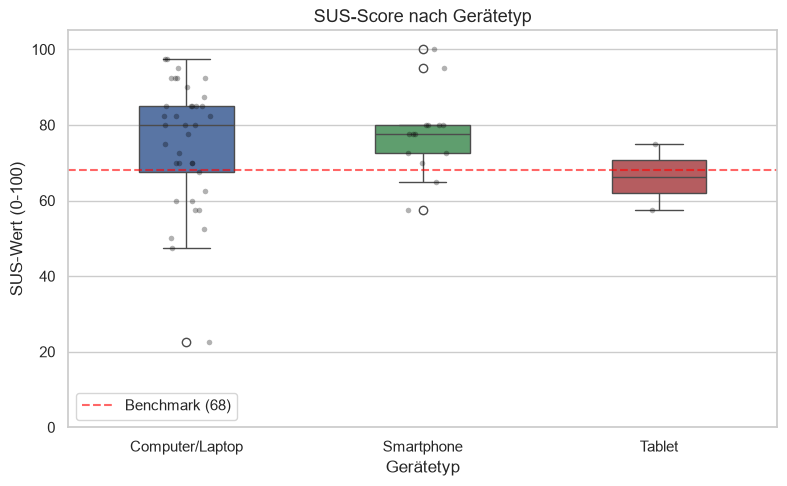

In [34]:
# VISUELLER CHECK NACH GERÄTETYP / DE04 (SUS)
if 'DE04' in df.columns:
    # Definition der drei Kategorien aus der Befragung
    de04_map = {
        1: 'Computer/Laptop', 
        2: 'Smartphone',
        3: 'Tablet'
    }
    
    # Filtern und Mappen der Kategorien
    df_de04 = df[df['DE04'].isin(de04_map)].copy()
    df_de04['Gerätetyp'] = df_de04['DE04'].map(de04_map)
    
    # Farben für die drei Kategorien definieren
    de04_colors = {
        'Computer/Laptop': '#4c72b0',  # Blau
        'Smartphone': '#55a868',       # Grün
        'Tablet': '#c44e52'            # Rot/Terracotta
    }

    plt.figure(figsize=(8, 5))
    ax2 = sns.boxplot(
        data=df_de04,
        x='Gerätetyp',
        y='SUS_Score',
        hue='Gerätetyp',
        palette=de04_colors,
        width=0.4,
        legend=False
    )

    # Einzelne Datenpunkte darüberlegen, um die Verteilung zu zeigen
    sns.stripplot(
        data=df_de04,
        x='Gerätetyp',
        y='SUS_Score',
        color='black',
        alpha=0.3,
        size=4,
        jitter=0.1
    )

    # Benchmark-Linie und Beschriftungen anpassen
    ax2.axhline(y=68, color='red', linestyle='--', alpha=0.6, label='Benchmark (68)')
    ax2.set_title('SUS-Score nach Gerätetyp')
    ax2.set_ylim(0, 105)
    ax2.set_ylabel('SUS-Wert (0-100)')
    ax2.set_xlabel('Gerätetyp')
    ax2.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

#### Interpretation des System Usability Scale (SUS) Scores nach Gerätetyp (Explorative Analyse)

Der kombinierte Box- und Stripplot stellt die Verteilung der Usability-Werte explorativ zwischen den drei genutzten Gerätetypen gegenüber (rote gestrichelte Linie markiert den Usability-Benchmark von 68.0 nach Bangor et al., 2008):

* Robuste Kern-Usability auf Hauptkanälen: Die beiden primären E-Commerce-Kanäle übertreffen das geforderte Mindest-Gütekriterium deutlich. Computer/Laptop (Blau) erzielt den höchsten Median ($\approx 80$; Kategorie "Excellent"), weist jedoch auch die größte Gesamtstreuung auf. Smartphones (Grün) demonstrieren mit einem Median von $\approx 78$ und einer stark komprimierten Box eine hohe, konsistente ergonomische Zufriedenheit im mobilen Segment.
* Empirische Relativierung des Tablet-Segments: Die Tablet-Klasse (Rot) verfehlt mit einem Median von $\approx 66$ Punkten als einzige Gruppe den Usability-Benchmark. Das integrierte Punktestreudiagramm offenbart hierbei die methodische Ursache: Das Segment umfasst eine minimale Fallzahl von lediglich $n = 2$ Probanden. Die deskriptiven Kennwerte dieser Gruppe besitzen daher keine statistische Generalisierbarkeit, liefern jedoch wertvolle qualitative Impulse für zukünftige UI-Optimierungen.
* Verortung des globalen Minimums: Der fundamentale Usability-Ausreißer der Gesamtevaluation ($\approx 22$ Punkte) ist eindeutig der Desktop-Kohorte (Computer/Laptop) zuzuordnen.

**Fazit:** Die Verteilungsanalyse verifiziert eine hervorragende ergonomische Implementierung des Next.js-Prototyps *CtxCommerce* für Desktop- und Smartphone-Schnittstellen. Die scheinbare Tablet-Schwäche lässt sich methodisch auf eine extreme Unterrepräsentanz im Datensatz zurückführen. Für das Diskussionskapitel (Kapitel 7) bedeutet dies, dass das System für die kommerziell relevanten Hauptkanäle (Desktop & Mobile) als vollkommen marktreif eingestuft werden kann.